# Unit Test Notebook for Gripper class functions

In [1]:
import asyncio
import sys
import time
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import magpie_control.gripper as g
from magpie_control.gripper import Gripper

import magpie_control.ur5 as u
from magpie_control import ur5
import importlib
importlib.reload(g)
importlib.reload(u)

<module 'magpie_control.ur5' from '/home/will/workspace/magpie_control/src/magpie_control/ur5.py'>

In [2]:
servoport = '/dev/ttyACM0'
G = Gripper(servoport=servoport, debug=False)

r = ur5.UR5_Interface(robotIP="192.168.0.4")
r.start()

r.start_ft_sensor(ip_address="192.168.0.5", poll_rate=100)
print(f"{r.get_ft_data()=}")

Succeeded to open the port
Succeeded to change the baudrate
r.get_ft_data()=[0.1, 0.0, 0.1, -0.00899, -0.023, -0.001]


In [3]:
r.toggle_teach_mode()

In [3]:
r.start_ft_sensor(ip_address="192.168.0.5", poll_rate=100)
print(r.get_ft_data())
# print (r.get_ft_data()) every 0.5s
# while True:
#     print(r.get_ft_data())
#     time.sleep(0.5)
# await r.moveL_delta_async([-0.0, -0.0, 0.0125], frame="base", z_offset=0)
# await r.moveL_delta_async([-0.0, -0.0, 0.025], frame="wrist", z_offset=0)
# await r.moveL_delta_async([-0.0, 0.025, -0.00], frame="wrist")
# await r.moveL_delta_async([-0.025, -0.0, -0.00], frame="wrist")

[0.0, 0.0, 0.1, -0.00899, -0.006, 0.008]


In [4]:
import numpy as np
def wrench_wrist_to_base(robot):
    wrist = np.array(robot.getPose())
    wrench = robot.get_ft_data()
    R = wrist[:3, :3]
    p = wrist[:3, 3]
    force_w = np.array(wrench[:3])
    torque_w = np.array(wrench[3:])
    force_b = R @ force_w
    # Torque in base frame: T_B = R_{SB} * T_S + r_{SB} x (R_{SB} * F_S)
    torque_b = R @ torque_w + np.cross(p, force_b)
    wrench_b = np.hstack((force_b, torque_b))

    return wrench, wrench_b

def wrench_base_to_wrist(robot, wrench_b):
    wrist = np.array(robot.getPose())
    R = wrist[:3, :3]
    p = wrist[:3, 3]
    Rb = R.T  # R.inv() = R.T for rotation matrices
    pb = -Rb @ p  # inverse translation
    force_b = np.array(wrench_b[:3])
    torque_b = np.array(wrench_b[3:])
    force_w = Rb @ force_b
    # Torque in wrist frame: T_S = R_{SB}^T * T_B - r_{SB} x (R_{SB}^T * F_B)
    torque_w = Rb @ (torque_b - np.cross(p, force_b))
    wrench_w = np.hstack((force_w, torque_w))

    return wrench_w

print(f"robot wrist pose: {r.getPose()}")

wrench, wrench_b = wrench_wrist_to_base(r)
print(f"{wrench=}")
print(f"{wrench_b.round(3).tolist()=}")

goal_wrench_base = np.array([0, 5, 5, 0, 0, 0])
goal_wrench_wrist = wrench_base_to_wrist(r, wrench_b)
# goal_wrench_wrist = wrench_base_to_wrist(r, goal_wrench_base)
print(f"{goal_wrench_wrist.round(3).tolist()=}")

robot wrist pose:    0.07653   0.9321   -0.3541   -0.1122    
   0.472    -0.3467   -0.8106   -0.3406    
  -0.8783   -0.1051   -0.4665    0.2188    
   0         0         0         1         

wrench=[0.0, 0.0, -0.2, -0.006, 0.014, 0.004]
wrench_b.round(3).tolist()=[0.071, 0.162, 0.093, -0.056, 0.015, 0.008]
goal_wrench_wrist.round(3).tolist()=[-0.0, -0.0, -0.2, -0.006, 0.014, 0.004]


In [19]:
G.reset_packet_overload()
G.reset_parameters()

In [21]:
async def reset_and_close_gripper(gripper, force_limit=2, duration=-1):
    def close_gripper(g, force=2):
        g.reset_packet_overload(force_limit=force_limit)
        g.close_gripper()
    start = time.time()
    if duration < 0:
        close_gripper(gripper, force=force_limit)
        return
    while time.time() - start < duration:
        close_gripper(gripper, force=force_limit)
        await asyncio.sleep(0.25)

# rotation matrix with -1, 1, -1 on diagonal
def orient_TCP_down(r):
    """orient TCP facing down toward the table, z-axis down"""
    R = np.array([[-1, 0, 0], [0, 1, 0], [0, 0, -1]])
    p = np.array(r.getPose())
    p[:3, :3] = R
    r.moveL(p)

import matplotlib.pyplot as plt

def plot_cf_ft(cf, ft, plot_cf=True, plot_ft=True):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    if plot_cf:
        cf = np.array(cf)
        ax1.plot(cf[:, 0], label='left')
        ax1.plot(cf[:, 1], label='right')
        ax1.set_title("Finger Contact Forces")
        ax1.legend()
    if plot_ft:
        ft = np.array(ft)
        ax2.plot(ft[:, 0], label='fx')
        ax2.plot(ft[:, 1], label='fy')
        ax2.plot(ft[:, 2], label='fz')
        # plt.plot(ft[:, 3], label='tx')
        # plt.plot(ft[:, 4], label='ty')
        # plt.plot(ft[:, 5], label='tz')
        ax2.set_title("Wrist Forces")
        ax2.legend()
    fig.tight_layout()
    plt.show()

# orient_TCP_down(r)
await reset_and_close_gripper(G, force_limit=20)

[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!


In [32]:
# these functions only work when the wrist and base Z are parallel
async def maintain_force(robot, force, axis="z", duration = 5, tolerance = 0.1, delta=0.0005):
    force = min(3, force)
    ft = robot.get_ft_data()
    axis = {"x": 0, "y": 1, "z": 2}[axis]
    delta_vector = [0, 0, 0]
    delta_vector[axis] = delta
    start = time.time()
    # measure the first motion and flip direction in force is already too high
    prev_force = ft[axis]
    direction = 1
    while time.time() - start < duration:
        ft = robot.get_ft_data()
        current_force = ft[axis]
        if abs(current_force - force) < tolerance:
            print(f"Stop force: {current_force}")
            continue
        # z axis into table only: as --> -z, so does -z force
        direction = -1 if current_force > force else 1
        # print(f"Z pos: {robot.recv.getActualTCPPose()[2]}")
        await robot.moveL_delta_async(direction * np.array(delta_vector), z_offset=0.0)
        # time.sleep(0.045)
        await asyncio.sleep(0.01)
        prev_force = current_force
    
    return current_force

# this only works when the wrist and base Z are parallel
async def maintain_force_speed(robot, force, axis="z", duration = 5, tolerance = 0.1, delta=0.0005):
    force = min(3, force)
    ft = robot.get_ft_data()
    axis = {"x": 0, "y": 1, "z": 2}[axis]
    delta_vector = [0, 0, 0]
    delta_vector[axis] = delta
    delta_vector = np.hstack((delta_vector, np.zeros(3)))
    start = time.time()
    # measure the first motion and flip direction in force is already too high
    prev_force = ft[axis]
    direction = 1
    while time.time() - start < duration:
        ft = robot.get_ft_data()
        print(f"{ft=}")
        current_force = ft[axis]
        if abs(current_force - force) < tolerance:
            print(f"Stop force Z-force: {current_force}")
            continue
        # z axis into table only: as --> -z, so does -z force
        # direction = -1 if current_force > force else 1
        direction = 1 if current_force > force else -1
        speedL_cmd = direction * np.array(delta_vector)
        # print(f"Z pos: {robot.recv.getActualTCPPose()[2]}\n{speedL_cmd=}")
        print(f"Z-speed {speedL_cmd[2]=}")
        await robot.speedL_TCP(speedL_cmd)
        # time.sleep(0.045)
        await asyncio.sleep(0.01)
        prev_force = current_force
    
    return current_force

# await asyncio.gather(
#     G.deligrasp_async(10, 2.0, 2, 0.4, complete=True, debug=False),
#     maintain_force(r, -0.5, axis="z", duration=7, tolerance=0.1, delta=0.0015),
# )

# await asyncio.gather(
#     G.deligrasp_async(40, 1.0, 2, 0.4, complete=True, debug=False),
#     maintain_force_speed(r, -0.5, axis="z", duration=5, tolerance=0.1, delta=0.005),
# )
r.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)

In [30]:
r.ctrl.speedL([0.00, -0.00, 0.0, 0.0, 0.0, 0.0], 0.5, 0.25)
# r.ctrl.speedL([0.00, -0.00, 0.01, 0.0, 0.0, 0.0], 0.5, 0.25)

True

In [29]:
# await r.speedL_TCP([0.00, -0.0, -0.05, 0.0, 0.0, 0.0], 0.5, 0.25)
# await r.speedL_TCP([-0.03, -0.0, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
# await r.speedL_TCP([-0.01, -0.01, -.00, 0.0, 0.0, 0.0], 0.5, 0.25)
# await r.speedL_TCP([0.01, -0.00, -.00, 0.0, 0.0, 0.0], 0.5, 0.25)
await r.speedL_TCP([-0.01, -0.00, 0.03, 0.0, 0.0, 0.0], 0.5, 0.25)
# await r.speedL_TCP([0.00, -0.02, -0.07, 0.0, 0.0, 0.0], 0.5, 0.25)

In [104]:
# r.ctrl.getJointTorques()

# wrench_goal = np.array([-15, 3, -3, 0, 0, 0]) # for push cart
# wrench_goal = np.array([15, -3, 3, 0, 0, 0]) # for pulling cart
# init_cmd = np.hstack((wrench_goal[:3] / -300, np.zeros(3)))
# await r.speedL_TCP(init_cmd, 0.5, 0.25)

[0.0, 0.1, 0.3, 0.001, -0.005, -0.005]
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
Contact force command: [-0.021 -0.     0.018  0.     0.     0.   ]
ft_meas=[-2.8, -0.6, -2.0, 0.017, -0.439, 0.041]
pose[:3, 3]=array([0.44 , 0.053, 0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.090
TCP velocity: [-1.132e-03  1.526e-04 -4.936e-04  5.711e-04  4.294e-03 -4.225e-06]
Contact force command: [-0.025 -0.     0.019  0.     0.     0.   ]
ft_meas=[-3.2, -0.7, -2.5, 0.035, -0.489, 0.052]
pose[:3, 3]=array([0.44 , 0.053, 0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.090
TCP velocity: [-6.626e-04  8.853e-05 -2.587e-04  4.298e-04  3.257e-03 -4.269e-06]
Contact force command: [-0.029 -0.     0.02   0.     0.     0.   ]
ft_meas=[-3.6, -0.7, -3.5, 0.03, -0.527, 0.048]
pose[:3, 3]=array([0.44 , 0.053, 0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.090
TCP velocity: [ 1.782e-03 -2.163e-04

RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!


Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[39.0, 1.6, -20.4, 0.364, 4.903, 0.044]
pose[:3, 3]=array([ 0.428,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.098
TCP velocity: [ 0.005 -0.     0.005 -0.005 -0.032  0.003]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[35.4, 0.7, -17.8, 0.38, 4.322, 0.021]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [ 0.005 -0.001  0.006 -0.002 -0.022  0.001]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[30.5, 0.6, -11.6, 0.271, 3.702, 0.015]
pose[:3, 3]=array([ 0.429,  0.055, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [-0.     0.001  0.002 -0.    -0.002  0.004]


RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!


Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[30.8, 1.2, -15.7, 0.336, 3.788, 0.01799]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [ 0.    -0.001 -0.002  0.001  0.005 -0.002]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[31.2, 0.6, -11.9, 0.292, 3.77, 0.012]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [ 0.001  0.     0.002 -0.001 -0.004  0.001]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[30.2, 0.7, -13.7, 0.306, 3.651, 0.017]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [-3.296e-04  3.027e-04  1.785e-04 -6.759e-05 -3.906e-04  9.034e-04]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[31.2, 0.6, -14.7, 0.329, 3.817, 0.017]
pose[:3, 3]=array([ 0.429,  0.054, -0.

RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!


Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[29.8, 0.6, -12.6, 0.279, 3.667, 0.01799]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [ 3.890e-05  8.841e-06  1.045e-05 -7.571e-05 -3.077e-04  2.037e-04]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[30.2, 0.6, -15.7, 0.31, 3.71, 0.01799]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [ 2.211e-04 -1.845e-05  2.594e-04 -1.616e-04 -1.008e-03  1.713e-04]
Contact force command: [ 0.05 -0.   -0.05  0.    0.    0.  ]
ft_meas=[29.6, 0.5, -13.2, 0.275, 3.627, 0.014]
pose[:3, 3]=array([ 0.429,  0.054, -0.004])
goal_pose[:3, 3]=array([ 0.52 ,  0.045, -0.036])
Distance: 0.097
TCP velocity: [ 5.938e-04 -7.215e-05  7.458e-04 -1.969e-04 -2.445e-03  6.546e-05]
[[9.09198339, 1.2318225099999998], [9.09198339, 1.2318225099999998], [9.09198339, 1.23182250999999

RTDEControlInterface: RTDE control script is not running!
RTDEControlInterface: RTDE control script is not running!


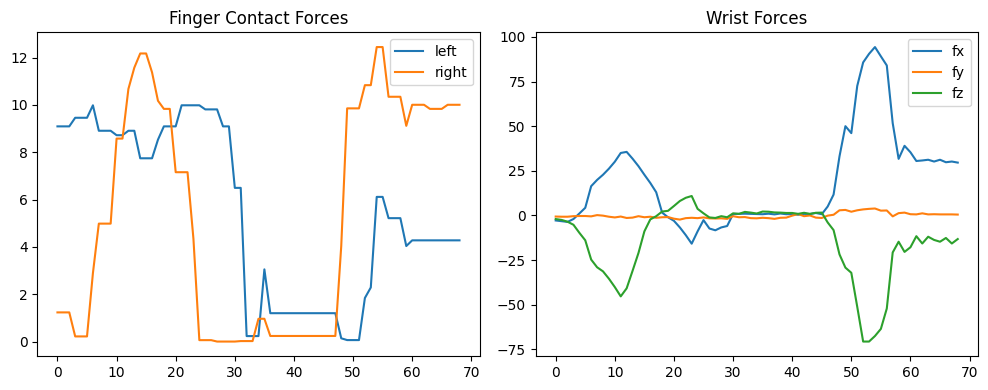

In [31]:
# cartesian force-position control
import spatialmath as sm
axes = {0: "x", 1: "y", 2: "z", 3: "rx", 4: "ry", 5: "rz"}

cf_t, ft_t = [], [] # contact force and force-torque data over time
r.start_ft_sensor(ip_address="192.168.0.5", poll_rate=100)
time.sleep(0.25)
print(r.get_ft_data())

async def force_position_control(robot, wrench=[0,0,0,0,0,0], 
                         goal_delta=[0,0,0], max_force=10, init_cmd=np.zeros(6),
                         duration = 5, tolerance = 0.1, p=0.0005, control_type="bang_bang"):

    def get_contact_force_update(cmd=np.zeros(6), cf=np.zeros(2), p=0.0005,
                                 tolerance=3, control_type="bang_bang"):
        '''
        @param cmd: 6D command speed at the wrist TCP
        @param cf: 2D contact force at the gripper fingers, cf[0] = right, cf[1] = left
        @param tolerance: force tolerance for imbalance between left and right fingers
        @param control_type: "bang_bang" or "proportional"
        @return: 6D command speed at the wrist TCP updated for balanced left and right finger forces
        the contact forces are always on the gripper wrist X-axis
        '''
        error = cf[0] - cf[1]
        if np.abs(error) < tolerance:
            return cmd
        print(f"Contact force imbalance: {error}")
        if control_type == "bang_bang":
            sign = np.ones(6)
            sign[0] = -1
            return cmd * sign
        elif control_type == "proportional":
            update = p * (cf[0] - cf[1])
            # set absolute velocity limit to 0.05
            cmd[0] += update
            cmd = np.clip(cmd, -0.05, 0.05)
            # print(f"Contact force imbalance: {error}")
            print(f"Contact force update: {update}")
            print(f"Contact force update cmd: {cmd}")
        return cmd

    def get_control_update(cmd=np.zeros(6), ft_goal=np.zeros(6), 
                           ft_meas=np.zeros(6), p=0.0005, control_type="bang_bang"):
        if control_type == "bang_bang":
            sign = np.ones(6)
            sign[np.abs(ft_meas) > np.abs(ft_goal)] = -1
            # print(f"Flipping: {[axes[i] for i in range(6) if sign[i] == -1 and wrench[i] != 0]}")
            return cmd * sign
        elif control_type == "proportional":
            update = p * (ft_goal - ft_meas)
            update[ft_goal == 0] = 0
            cmd = np.clip(cmd - update, -0.05, 0.05)
            return cmd
        return np.zeros(6)

    pose = np.array(robot.getPose())
    T_w = sm.SE3(goal_delta).A
    goal_pose = pose @ T_w
    distance = np.linalg.norm(goal_pose[:3, 3] - pose[:3, 3])
    ft_goal = np.array(wrench).clip(min=-1*max_force, max=max_force)
    speedL_cmd_w = init_cmd # initial cmd
    start = time.time()
    while time.time() - start < duration and distance > tolerance:
        ft_meas = robot.get_ft_data()
        # turns out left and right were switced in Gripper class
        cf_t.append([G.interval_force_measure(G.latency, 5, finger='right'), 
            G.interval_force_measure(G.latency, 5, finger='left')])
        ft_t.append(ft_meas)
        speedL_cmd_w = get_control_update(speedL_cmd_w, ft_goal, ft_meas, p=p, control_type=control_type)
        # print(f"SpeedL command: {speedL_cmd_w}")
        # speedL_cmd_w = get_contact_force_update(speedL_cmd_w, cf_t[-1], p=p, tolerance=3, control_type="bang_bang")
        # speedL_cmd_w = get_contact_force_update(speedL_cmd_w, cf_t[-1], p=p, tolerance=3, control_type="proportional")
        print(f"Contact force command: {speedL_cmd_w}")
        await robot.speedL_TCP(np.array(speedL_cmd_w))
        pose = np.array(robot.getPose())
        distance = np.linalg.norm(goal_pose[:3, 3] - pose[:3, 3])
        print(f"{ft_meas=}")
        print(f"{pose[:3, 3]=}\n{goal_pose[:3, 3]=}")
        print(f"Distance: {distance:.3f}")
        print(f"TCP velocity: {np.array(robot.recv.getActualTCPSpeed())}")
        await asyncio.sleep(0.01)
    
    print(cf_t, ft_t)
    return cf_t, ft_t

goal_delta = np.array([0, 0.000, 0.09])
# wrench_goal = np.array([0, -2, -15, 0, 0, 0]) # for bottle pushing
# wrench_goal = np.array([-0, 0, -0.5, 0, 0, 0]) # for picking up a credit card
# wrench_goal = np.array([-0, -0.25, -0.25, 0, 0, 0]) # for picking up a credit card at an angle
# wrench_goal = np.array([25, -0, -0.0, 0, 0, 0]) # for zipping a bag
# wrench_goal = np.array([-3, 0, -1, 0, 0, 0]) # close a lid
# wrench_goal = np.array([3, 0, 1, 0, 0, 0]) # open a lid
# wrench_goal = np.array([0.25, -2.0, -0.025, 0, 0, 0]) # usb insertion, usb perpendicular to gripper Z
# wrench_goal = np.array([2.5, -0, -0.0, 0, 0, 0]) # usb insertion, usb perpendicular to gripper Z
# wrench_goal = np.array([-15, 3, -5, 0, 0, 0]) # for push cart
# wrench_goal = np.array([-15, 3, 0, 0, 0, 0]) # for push cart
# wrench_goal = np.array([25, -3, 3, 0, 0, 0]) # for pulling cart
# wrench_goal = np.array([10, 0, 10, 0, 0, 0]) # for pulling cart
wrench_goal = np.array([5, 0, -5, 0, 0, 0]) # for pulling stool
# wrench_goal = np.array([5, 0, 5, 0, 0, 0]) # for pushing stool
init_cmd = np.hstack((wrench_goal[:3] / -300, np.zeros(3)))
grasp_force = 20
# direction = np.array([0, 0.005, 0.02])

dur = 4
await asyncio.gather(
    reset_and_close_gripper(G, force_limit=grasp_force, duration=dur),
    # G.deligrasp_async(40, grasp_force, 2, 0.4, complete=True, debug=False),
    # r.force_position_control(wrench=wrench_goal, goal_delta=goal_delta, 
    #                init_cmd=init_cmd, tolerance=0.01, duration=dur)
    force_position_control(r, wrench=wrench_goal, goal_delta=goal_delta, 
                #    init_cmd=init_cmd, tolerance=0.01, duration=dur, control_type="proportional")
                   init_cmd=init_cmd, tolerance=0.01, duration=dur, control_type="proportional")
)

dur = 6
# await asyncio.gather(
#     G.deligrasp_async(40, 2.0, 2, 0.4, complete=True, debug=False),
#     force_position(r, wrench=wrench_goal, goal_delta=goal_delta, 
#                    direction=direction, tolerance=0.01, duration=dur)
# )

r.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
plot_cf_ft(cf_t, ft_t)
# plot_cf_ft(r.cf_t, r.ft_t)

In [18]:
# import asyncio
# async def record(duration=10):
#     cf = []
#     ft = []
#     cam.begin_record(filepath='record/wrist/')
#     start = time.time()
#     # while True:
#     await asyncio.sleep(duration)
#     await cam.stop_record()

In [59]:
import rerun as rr
rr.init("force tracking", spawn=True)

rr.log("finger/left",
       rr.SeriesPoint(
        color=[255, 0, 0],
        name="Left Finger Contact Force",
        marker="circle",
        marker_size=4,
       ),
       static=True
       )

rr.log("finger/right",
       rr.SeriesPoint(
        color=[0, 255, 0],
        name="Right Finger Contact Force",
        marker="circle",
        marker_size=2,
       ),
       static=True
       )

def rr_log_vectors(name, vector, origins, color=[0, 0, 255], label="wrist forces"):
    rr.log(f"wrist/{name}",
       rr.Arrows3D(
        vectors=vector,
        origins=origins,
        labels=[label],
        colors=color,
        radii=0.03,
       ),
       static=True,
    )

start = time.time()
t = 0
ft = []
x, y, z, origins = [], [], [], []
r.start_ft_sensor()
time.sleep(0.5)
rr.set_time_seconds("time", time.time())
while time.time() - start < 10:
# while True:
    rr.set_time_sequence("step", t)
    t += 1
    cf = G.interval_force_measure(G.latency, 5, finger='both', distinct=True)
    await G.reset_and_close_gripper(force_limit=10)
    pos = np.array(r.getPose())[:3, 3]*100
    force = r.get_ft_data()[:3]
    origins.append(pos)
    ft.append(force if len(force) == 3 else [0, 0, 0])
    x.append([force[0], 0, 0])
    y.append([0, force[1], 0])
    z.append([0, 0, force[2]])
    rr_log_vectors("x", x, origins, color=[255, 0, 0], label="fx")
    rr_log_vectors("y", y, origins, color=[0, 255, 0], label="fy")
    rr_log_vectors("z", z, origins, color=[0, 0, 255], label="fz")
#     rr_log_vectors("xyz", ft, color=[0, 0, 0], label="ft")
    rr.log("finger/left", rr.Scalar(cf[0]))
    rr.log("finger/right", rr.Scalar(cf[1]))
    time.sleep(0.05)

[2025-04-04T19:23:10Z INFO  re_sdk_comms::server] Hosting a SDK server over TCP at 0.0.0.0:9876. Connect with the Rerun logging SDK.
[2025-04-04T19:23:10Z INFO  winit::platform_impl::linux::x11::window] Guessed window scale factor: 1
[2025-04-04T19:23:10Z INFO  re_sdk_comms::server] New SDK client connected from: 127.0.0.1:49244
[2025-04-04T19:23:10Z WARN  wgpu_hal::gles::egl] No config found!
[2025-04-04T19:23:10Z WARN  wgpu_hal::gles::egl] EGL says it can present to the window but not natively
[2025-04-04T19:23:10Z WARN  wgpu_hal::gles::adapter] Max vertex attribute stride unknown. Assuming it is 2048
[2025-04-04T19:23:10Z WARN  wgpu_hal::gles::adapter] Max vertex attribute stride unknown. Assuming it is 2048
[2025-04-04T19:23:10Z INFO  egui_wgpu] There were 3 available wgpu adapters: {backend: Vulkan, device_type: DiscreteGpu, name: "NVIDIA GeForce RTX 2070", driver: "NVIDIA", driver_info: "550.120", vendor: 0x10DE, device: 0x1F02}, {backend: Vulkan, device_type: Cpu, name: "llvmpip

[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!


In [47]:
ft

[[0.6, -0.3, -1.3],
 [-0.6, -0.7, -0.7],
 [-0.6, -0.7, -1.4],
 [-0.5, -0.7, -0.3],
 [-0.5, -0.7, -1.7],
 [-0.6, -0.8, -1.9],
 [-0.5, -0.7, -0.4],
 [-0.6, -0.7, -1.0],
 [-0.5, -0.8, -1.0],
 [-0.3, -0.8, -0.3],
 [-0.5, -0.8, -0.9],
 [-0.5, -0.9, -1.7],
 [0.1, -0.7, -0.6],
 [],
 [2.4, -0.5, 0.0],
 [1.8, -1.0, 0.6],
 [1.2, -0.5, 0.8],
 [3.2, -0.1, 0.3],
 [0.7, -1.0, -0.8],
 [-5.3, -1.7, -2.6],
 [-7.4, -1.9, -5.8],
 [-11.2, -2.5, -7.2],
 [-11.2, -2.6, -6.5],
 [-8.4, -1.9, -5.7],
 [-9.6, -3.1, -4.0],
 [-6.9, -1.4, -2.9],
 [-7.1, -1.5, -2.6],
 [-7.7, -1.4, -1.7],
 [-8.0, -1.5, -2.0],
 [-8.6, -0.1, -1.6],
 [-7.9, -0.7, -1.0],
 [-6.1, 0.1, -2.0],
 [-4.2, 2.3, -1.3],
 [-6.1, 1.5, -2.4],
 [-5.6, 1.5, -2.9],
 [-3.3, 3.1, -1.3],
 [-5.2, 0.0, -3.7],
 [-2.1, 0.9, -3.3],
 [-1.3, -0.4, -1.4],
 [-1.1, 0.6, -0.9],
 [-0.5, 1.1, -1.6],
 [-0.5, 1.1, -1.1],
 [-0.5, 0.9, -0.7],
 [-0.5, 0.6, -2.4],
 [-0.2, 0.9, 0.0],
 [0.5, 1.1, 1.1],
 [0.8, 1.1, -1.4],
 [2.6, 2.0, 0.2],
 [3.7, 0.9, 1.0],
 [4.2, 1.9, 1.4],
 [6

In [32]:
rr.datatypes.Vec3D

rerun.datatypes.vec3d.Vec3D

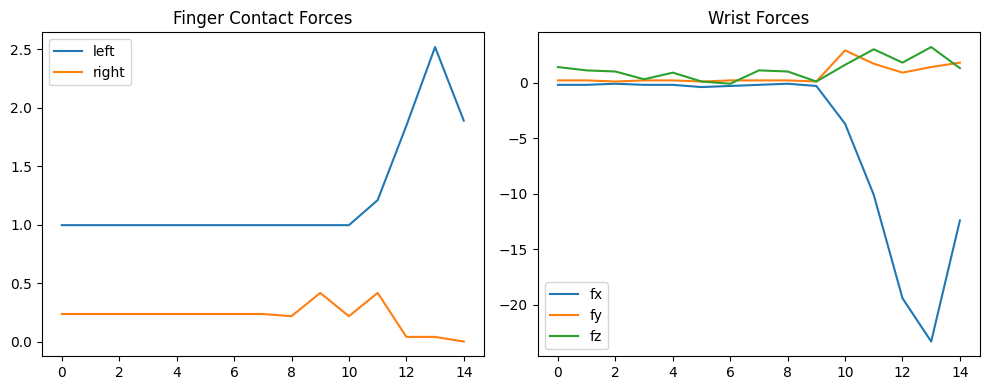

In [43]:
cf = []
ft = []
# await cam.stop_record()
# await record(5)
# cam.begin_record(filepath='record/workspace/')
start = time.time()
# await record(10)
# await reset_and_close_gripper(G, duration=5)
while time.time() - start < 2:
    cf.append([G.interval_force_measure(G.latency, 5, finger='right'), 
               G.interval_force_measure(G.latency, 5, finger='left')])
    ft.append(r.get_ft_data())
    await reset_and_close_gripper(G)
    # time.sleep(0.05)
# await cam.stop_record()
plot_cf_ft(cf, ft)

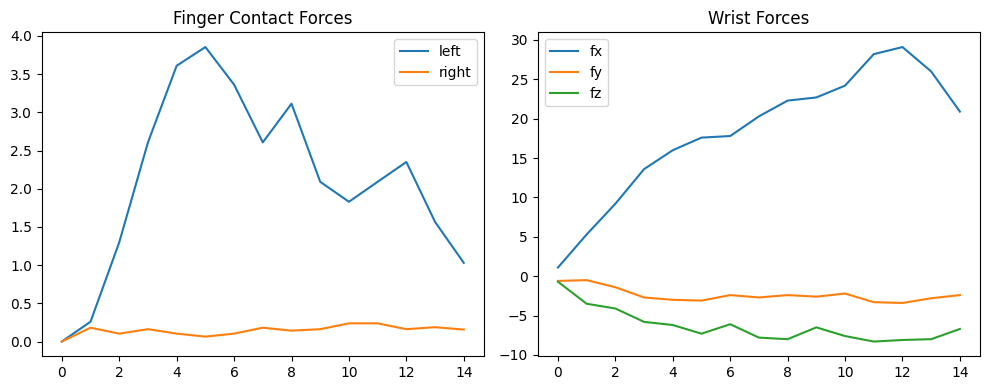